In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

# Generate 20 values for each team (realistic variation)
team1 = np.random.randint(60, 95, 20)
team2 = np.random.randint(55, 90, 20)
team3 = np.random.randint(50, 92, 20)

In [4]:
df = pd.DataFrame({
    "Team1": team1,
    "Team2": team2,
    "Team3": team3
})

print(df)


    Team1  Team2  Team3
0      88     79     84
1      74     81     63
2      67     82     66
3      80     70     85
4      78     69     89
5      82     57     53
6      70     61     51
7      70     75     55
8      83     63     91
9      83     72     53
10     62     58     78
11     81     79     67
12     61     68     75
13     83     63     83
14     89     80     59
15     61     56     85
16     80     74     63
17     92     82     80
18     71     61     64
19     81     62     57


In [5]:
df.to_csv("anova_team_data.csv", index=False)

In [9]:
# Convert wide → long format
df_long = df.melt(var_name="Team", value_name="Score")

print(df_long.head(3))

    Team  Score
0  Team1     88
1  Team1     74
2  Team1     67


In [10]:
from scipy import stats

df = pd.read_csv("anova_team_data.csv")


In [11]:
group_A = df["Team1"]
group_B = df["Team2"]
group_C = df["Team3"]

# Apply ANOVA
f_stat, p_value = stats.f_oneway(group_A, group_B, group_C)

In [12]:
print("F-statistic:", f_stat)
print("p-value:", p_value)

# Decision
alpha = 0.05

F-statistic: 2.800104183181212
p-value: 0.06918687127205794


In [13]:
if p_value < alpha:
    print("Reject Null Hypothesis (Significant difference exists)")
else:
    print("Fail to Reject Null Hypothesis (No significant difference)")

Fail to Reject Null Hypothesis (No significant difference)


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


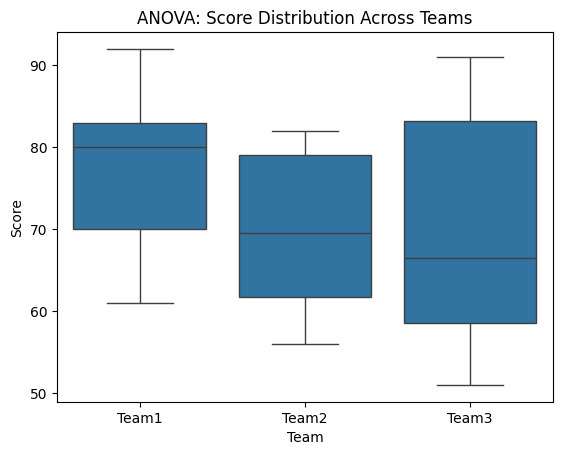

In [16]:
sns.boxplot(x="Team", y="Score", data=df_long)

plt.title("ANOVA: Score Distribution Across Teams")
plt.xlabel("Team")
plt.ylabel("Score")

plt.show()